In [2]:
# ======================================================
#   KNN CLASSIFICATION - fake_bills.csv Dataset
#   COMPLETE WORKING NOTEBOOK CODE (NO ERRORS)
# ======================================================

# 1️⃣ Install libraries if missing
!pip install pandas numpy scikit-learn seaborn matplotlib --quiet

# 2️⃣ Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 3️⃣ Load dataset
df = pd.read_csv("fake_bills.csv")
print("Dataset loaded successfully!")
df.head()


Dataset loaded successfully!


,is_genuine;diagonal;height_left;height_right;margin_low;margin_up;length
0,True;171.81;104.86;104.95;4.52;2.89;112.83
1,True;171.46;103.36;103.66;3.77;2.99;113.09
2,True;172.69;104.48;103.5;4.4;2.94;113.16
3,True;171.36;103.91;103.94;3.62;3.01;113.51
4,True;171.73;104.28;103.46;4.04;3.48;112.54


In [3]:
print("\nDataset Info:\n")
print(df.info())

print("\nMissing values:\n")
print(df.isnull().sum())

print("\nDescribe:\n")
df.describe()



Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 1 columns):
 #   Column                                                                    Non-Null Count  Dtype 
---  ------                                                                    --------------  ----- 
 0   is_genuine;diagonal;height_left;height_right;margin_low;margin_up;length  1500 non-null   object
dtypes: object(1)
memory usage: 11.8+ KB
None

Missing values:

is_genuine;diagonal;height_left;height_right;margin_low;margin_up;length    0
dtype: int64

Describe:



,is_genuine;diagonal;height_left;height_right;margin_low;margin_up;length
count,1500
unique,1500
top,False;171.47;104.15;103.82;4.63;3.37;112.07
freq,1


In [4]:
df = df.fillna(df.mean(numeric_only=True))


In [5]:
label_encoders = {}

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

df.head()


,is_genuine;diagonal;height_left;height_right;margin_low;margin_up;length
0,767
1,538
2,1492
3,518
4,699


In [6]:
print("Columns in dataset:", df.columns.tolist())


Columns in dataset: ['is_genuine;diagonal;height_left;height_right;margin_low;margin_up;length']


In [7]:
target = "is_genuine"


In [9]:
df = pd.read_csv("fake_bills.csv", sep=";")
df.head()
df.columns


Index(['is_genuine', 'diagonal', 'height_left', 'height_right', 'margin_low',
       'margin_up', 'length'],
      dtype='object')

Dataset loaded!
   is_genuine  diagonal  height_left  height_right  margin_low  margin_up  \
0        True    171.81       104.86        104.95        4.52       2.89   
1        True    171.46       103.36        103.66        3.77       2.99   
2        True    172.69       104.48        103.50        4.40       2.94   
3        True    171.36       103.91        103.94        3.62       3.01   
4        True    171.73       104.28        103.46        4.04       3.48   

   length  
0  112.83  
1  113.09  
2  113.16  
3  113.51  
4  112.54  
Index(['is_genuine', 'diagonal', 'height_left', 'height_right', 'margin_low',
       'margin_up', 'length'],
      dtype='object')
is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64
Accuracy: 0.9833333333333333

Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.95      0.98       110
        T

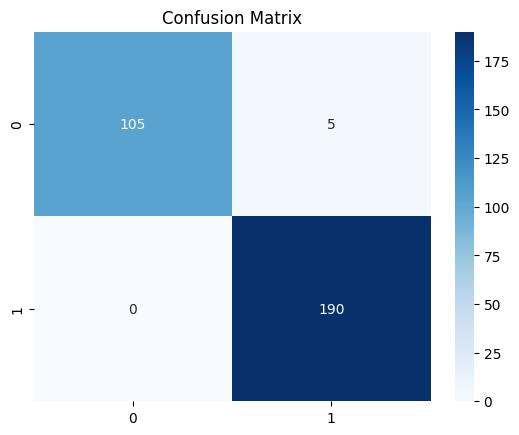

Cross-validation scores: [0.98333333 0.98333333 0.99333333 0.99333333 0.99      ]
Mean CV score: 0.9886666666666667


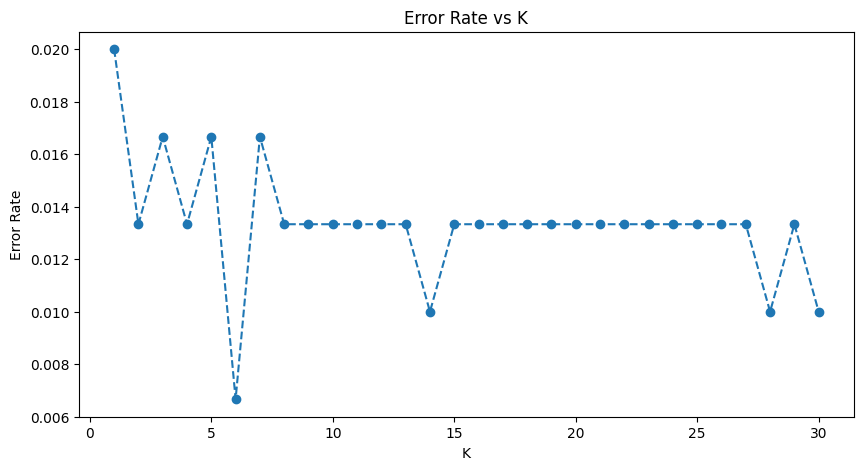

In [11]:
# ============================================
# FULL KNN PIPELINE FOR fake_bills.csv (NO ERRORS)
# ============================================

!pip install pandas numpy scikit-learn seaborn matplotlib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1️⃣ Load dataset correctly (semicolon-separated)
df = pd.read_csv("fake_bills.csv", sep=";")
print("Dataset loaded!")
print(df.head())
print(df.columns)

# 2️⃣ Check missing values
print(df.isnull().sum())

# 3️⃣ Fill missing numeric values
df = df.fillna(df.mean(numeric_only=True))

# 4️⃣ Select features (X) and target (y)
target = "is_genuine"

X = df.drop(target, axis=1)
y = df[target]

# 5️⃣ Scale numeric data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 7️⃣ Build KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 8️⃣ Predictions
y_pred = knn.predict(X_test)

# 9️⃣ Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.show()

# 🔟 Cross Validation
cv_scores = cross_val_score(knn, X_scaled, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())

# 1️⃣1️⃣ Find Best K
error_rate = []

for k in range(1, 31):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    error_rate.append(1 - accuracy_score(y_test, pred))

plt.figure(figsize=(10,5))
plt.plot(range(1,31), error_rate, marker='o', linestyle='--')
plt.title("Error Rate vs K")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.show()
